In [7]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import bayesflow as bf
pd.set_option("display.max_columns", 100)

In [8]:
from benchmark.examples.diffusion.config import MODELS, RESULT_DIR, TrainingConfig, ensure_dirs
from benchmark.examples.diffusion.dataset import wagenmakers
from benchmark.examples.diffusion.simulators import SIMULATORS
from benchmark.examples.diffusion.approximators.indirect import load_approximator, load_history
from benchmark.examples.diffusion.results.results import (
    attach_gold_standard,
    estimate_model_comparison,
    load_results,
    save_results,
)
from benchmark.examples.diffusion.results.summary_diagnostic import (
    add_summary_diagnostics,
    fit_references,
    load_diagnostic,
    load_references,
    save_diagnostic,
    save_references,
)
from benchmark.examples.diffusion.results.plots import (
    plot_logml_error_vs_rho,
    plot_pmp_error_vs_log_ambiguity,
    plot_pmp_error_vs_rho,
    plot_pmp_estimates_vs_distance,
)

ensure_dirs()


In [9]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


## 1. Load trained NPE approximators


In [10]:
config = TrainingConfig(epochs=50, batch_size=64, num_batches=64, summary_multiplier=2)
summary_tag = config.summary_label
results_path = RESULT_DIR / f"npe_{summary_tag}_results_gold.csv"
references_path = RESULT_DIR / f"npe_{summary_tag}_references.pkl"
diagnostic_path = RESULT_DIR / f"npe_{summary_tag}_empirical_diagnostic.csv"

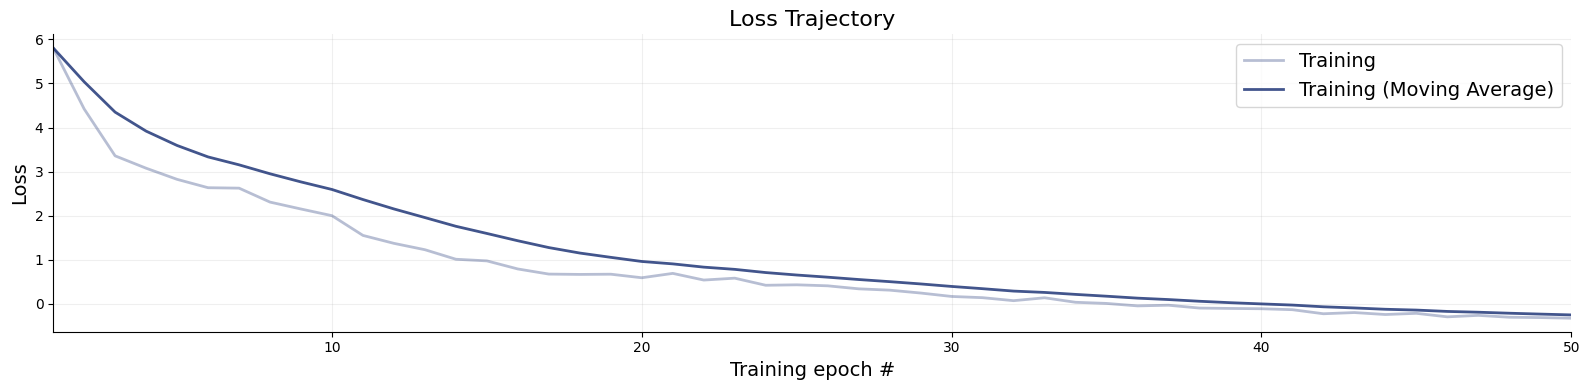

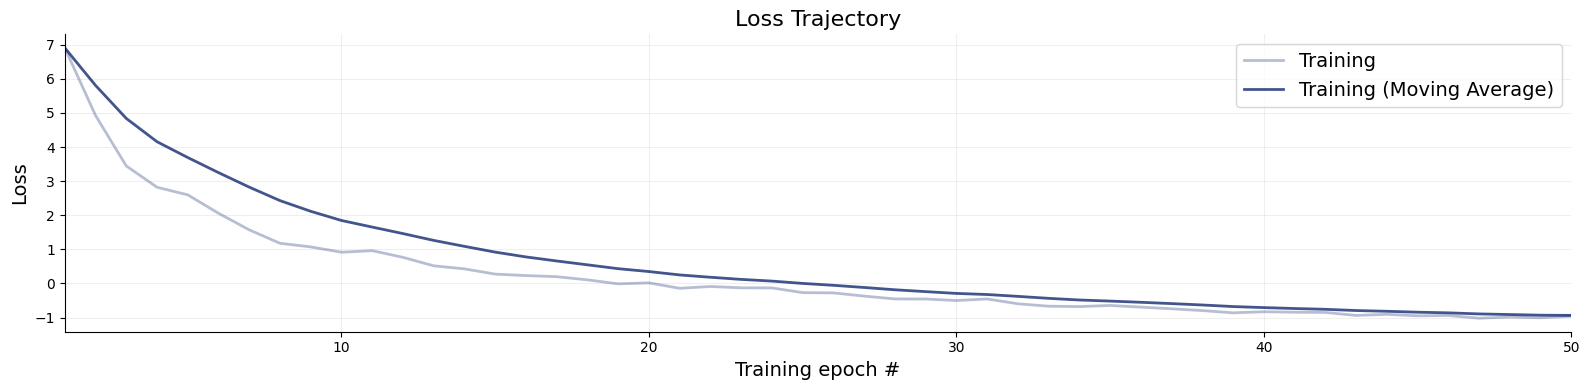

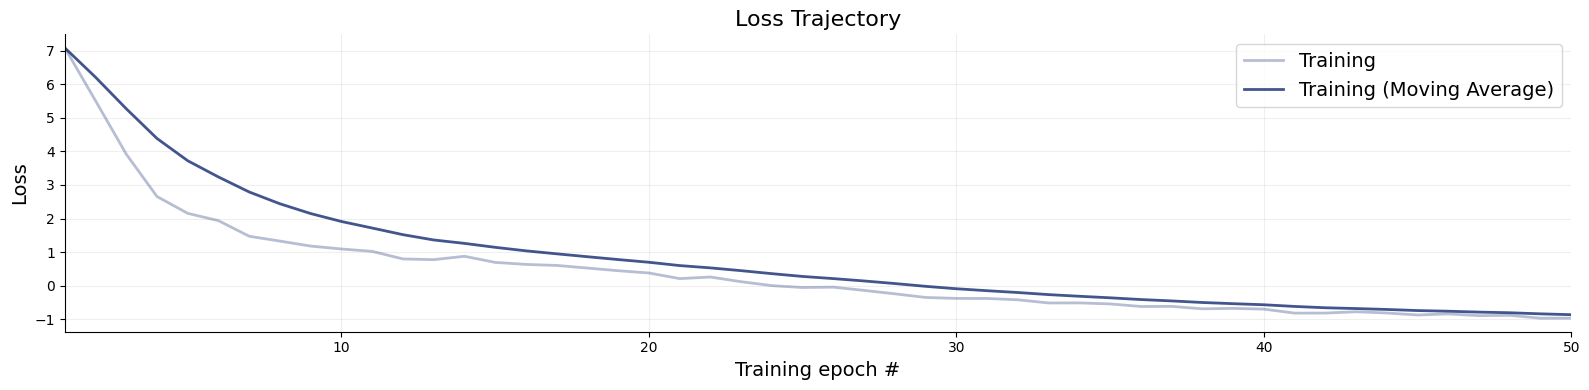

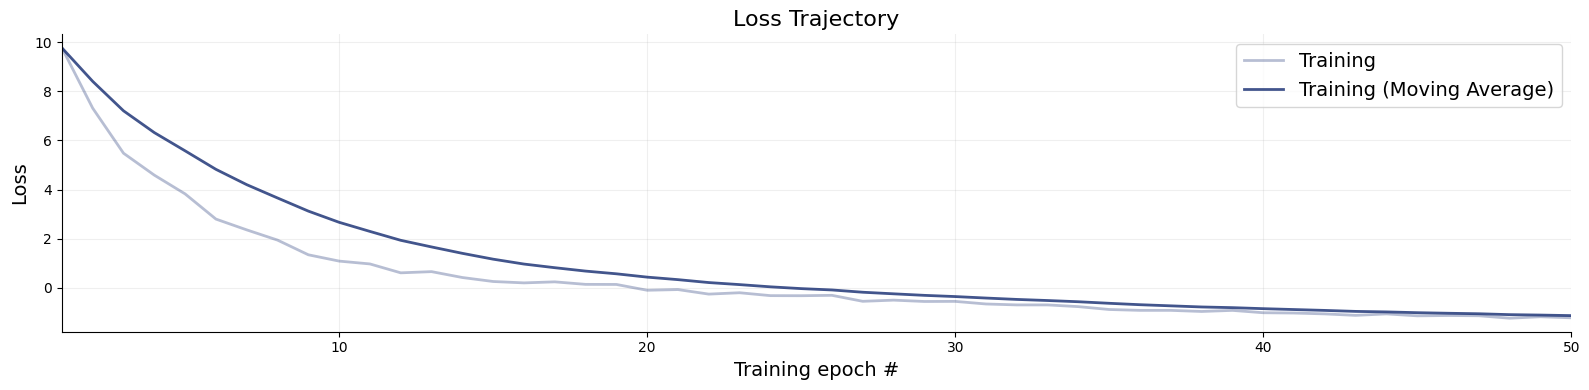

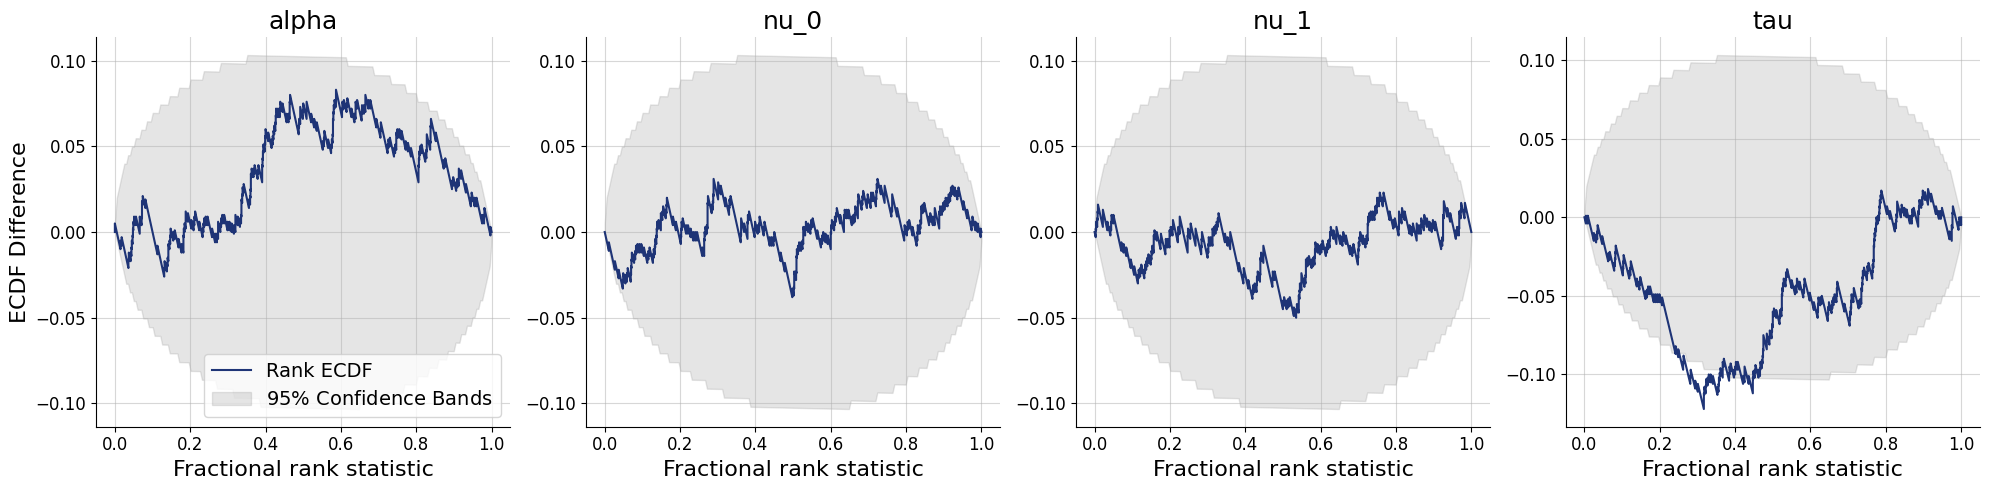

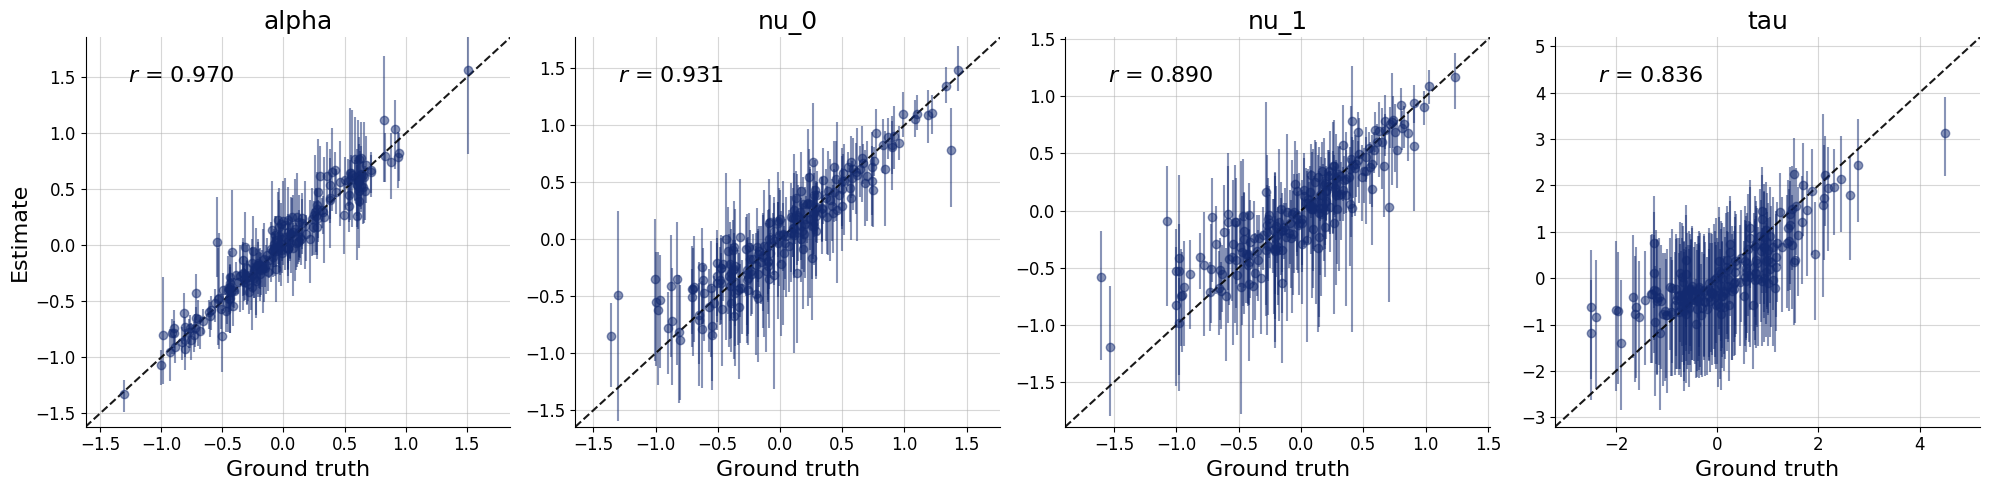

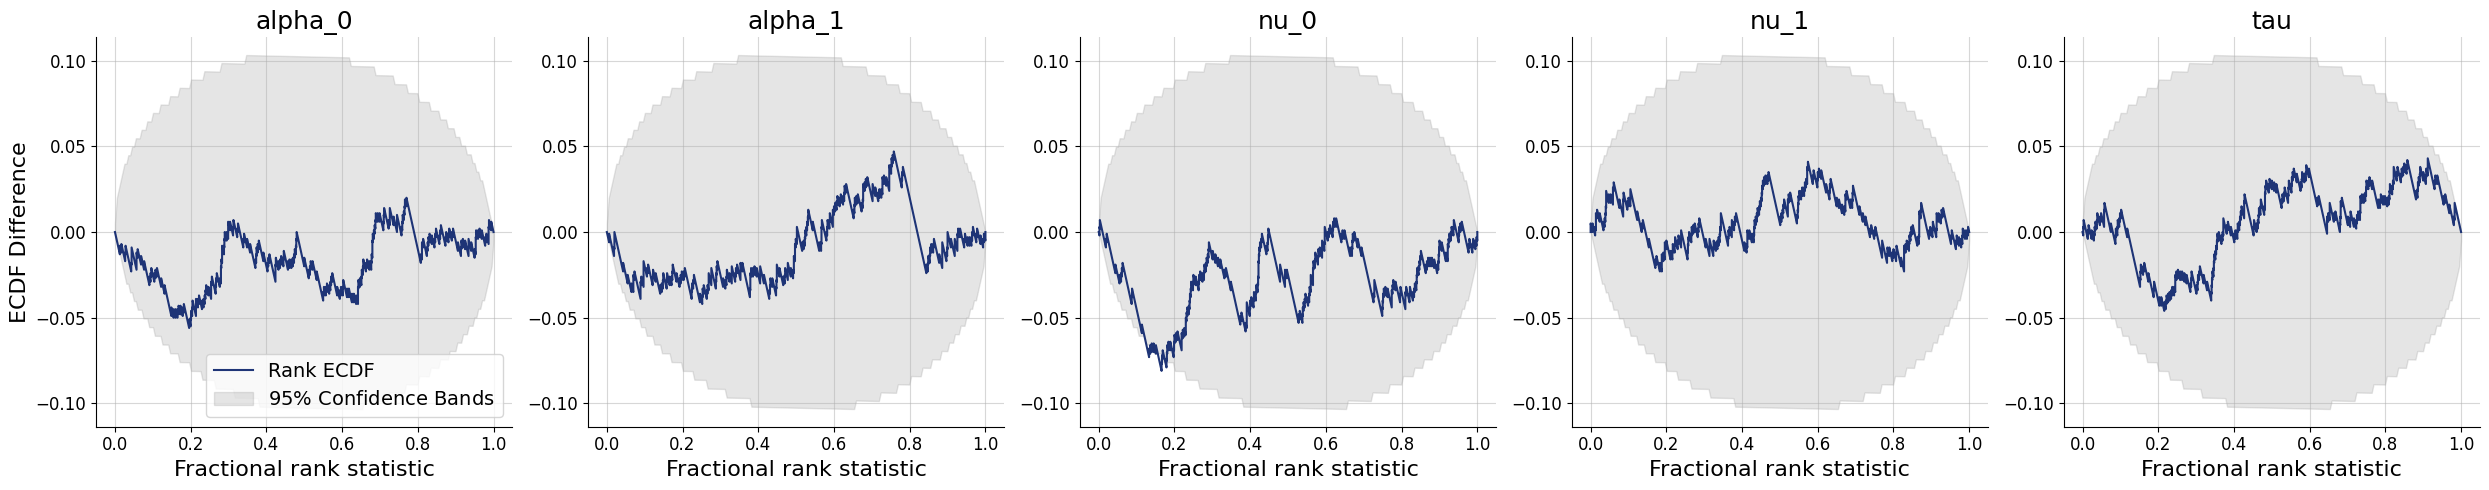

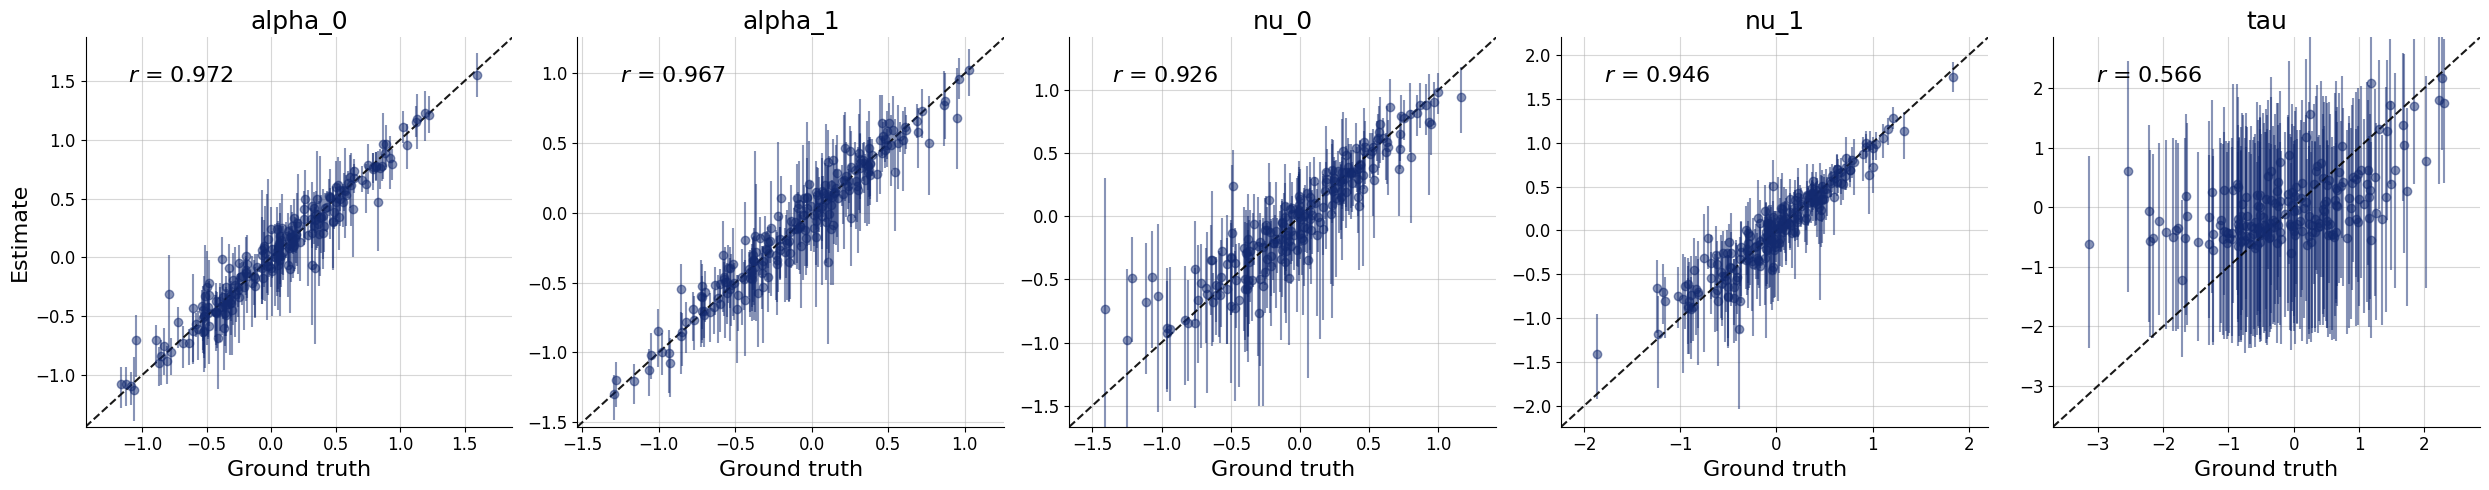

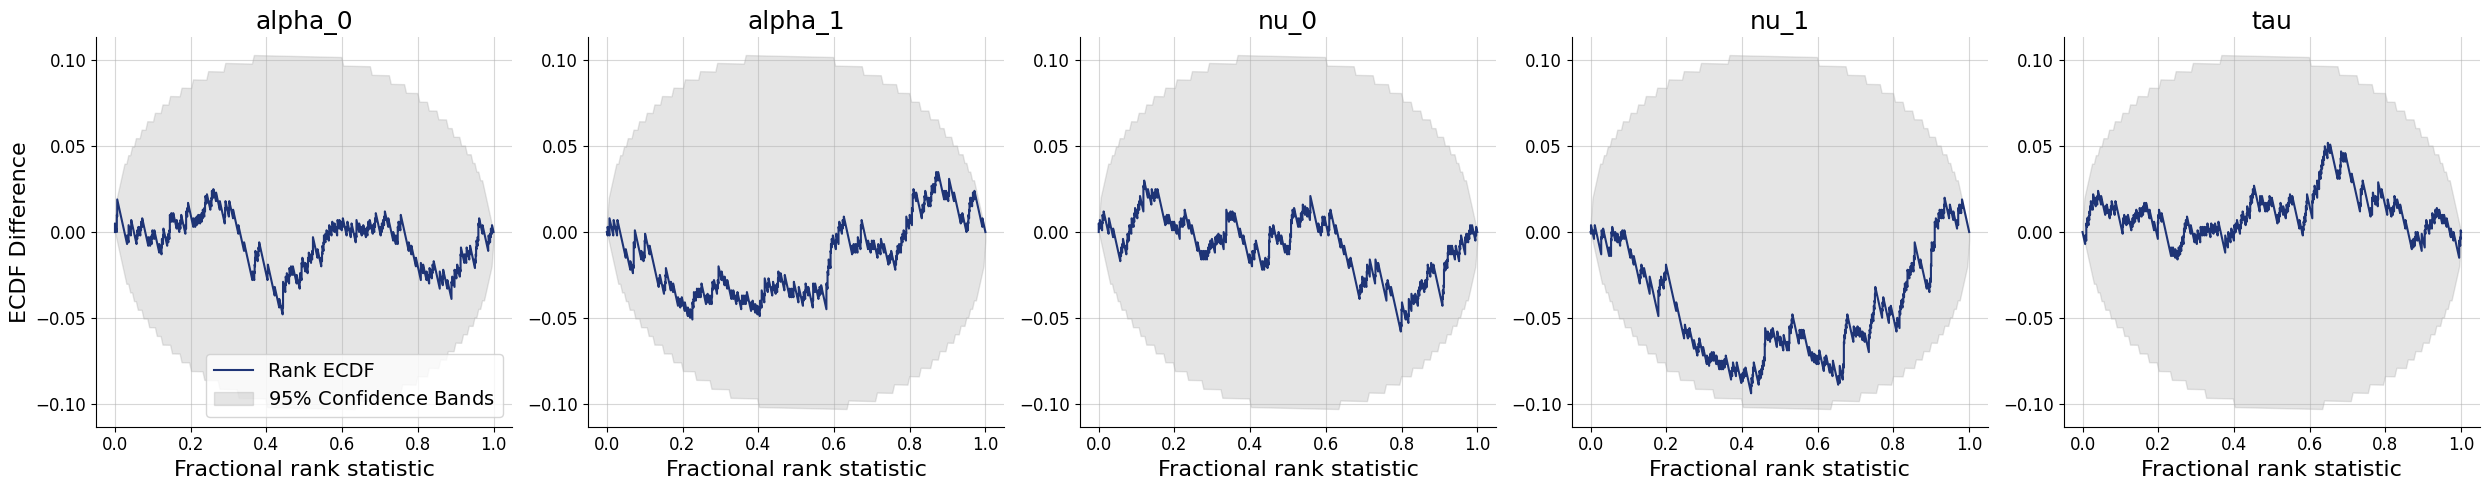

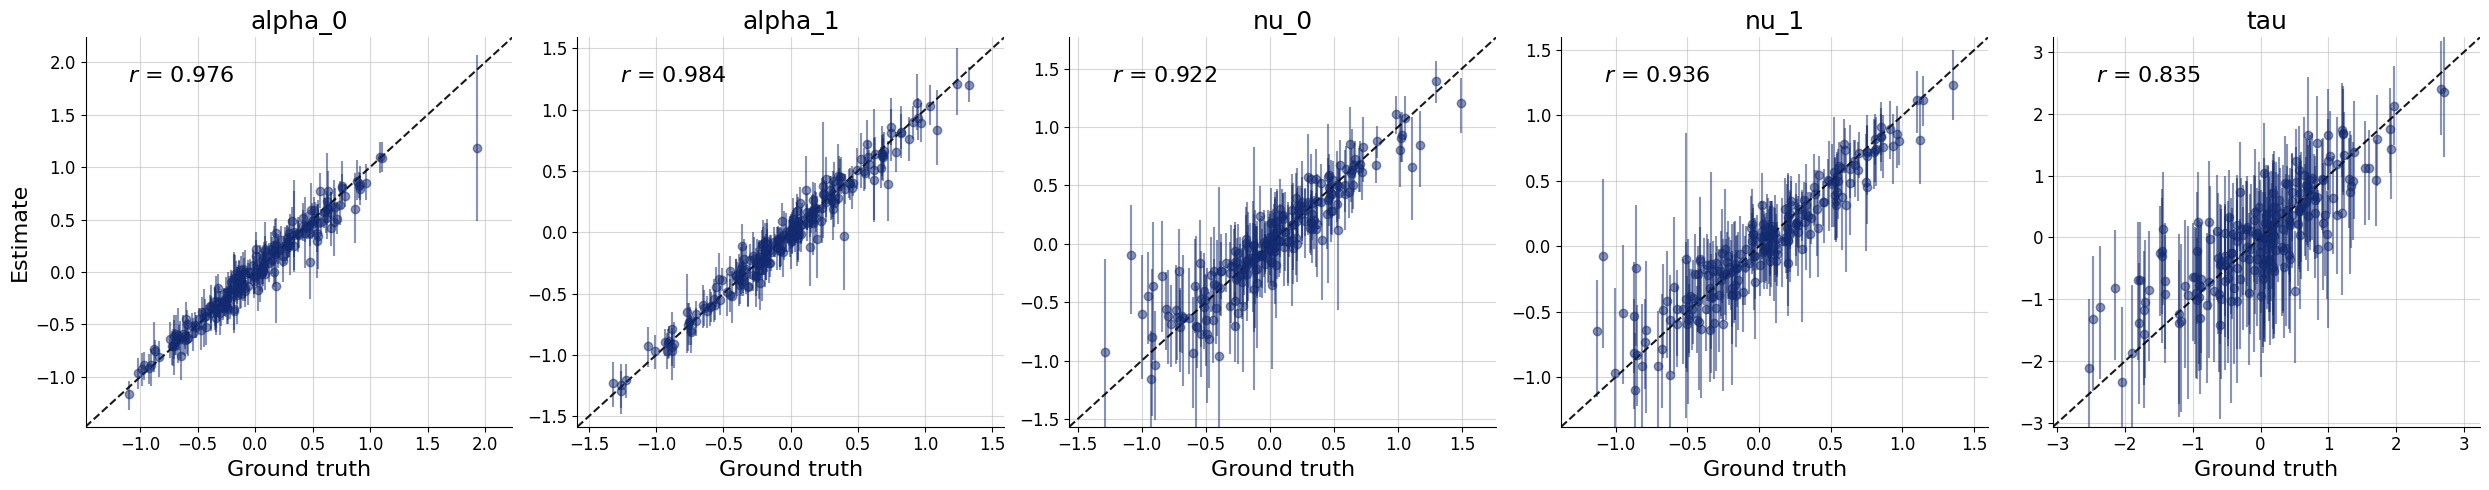

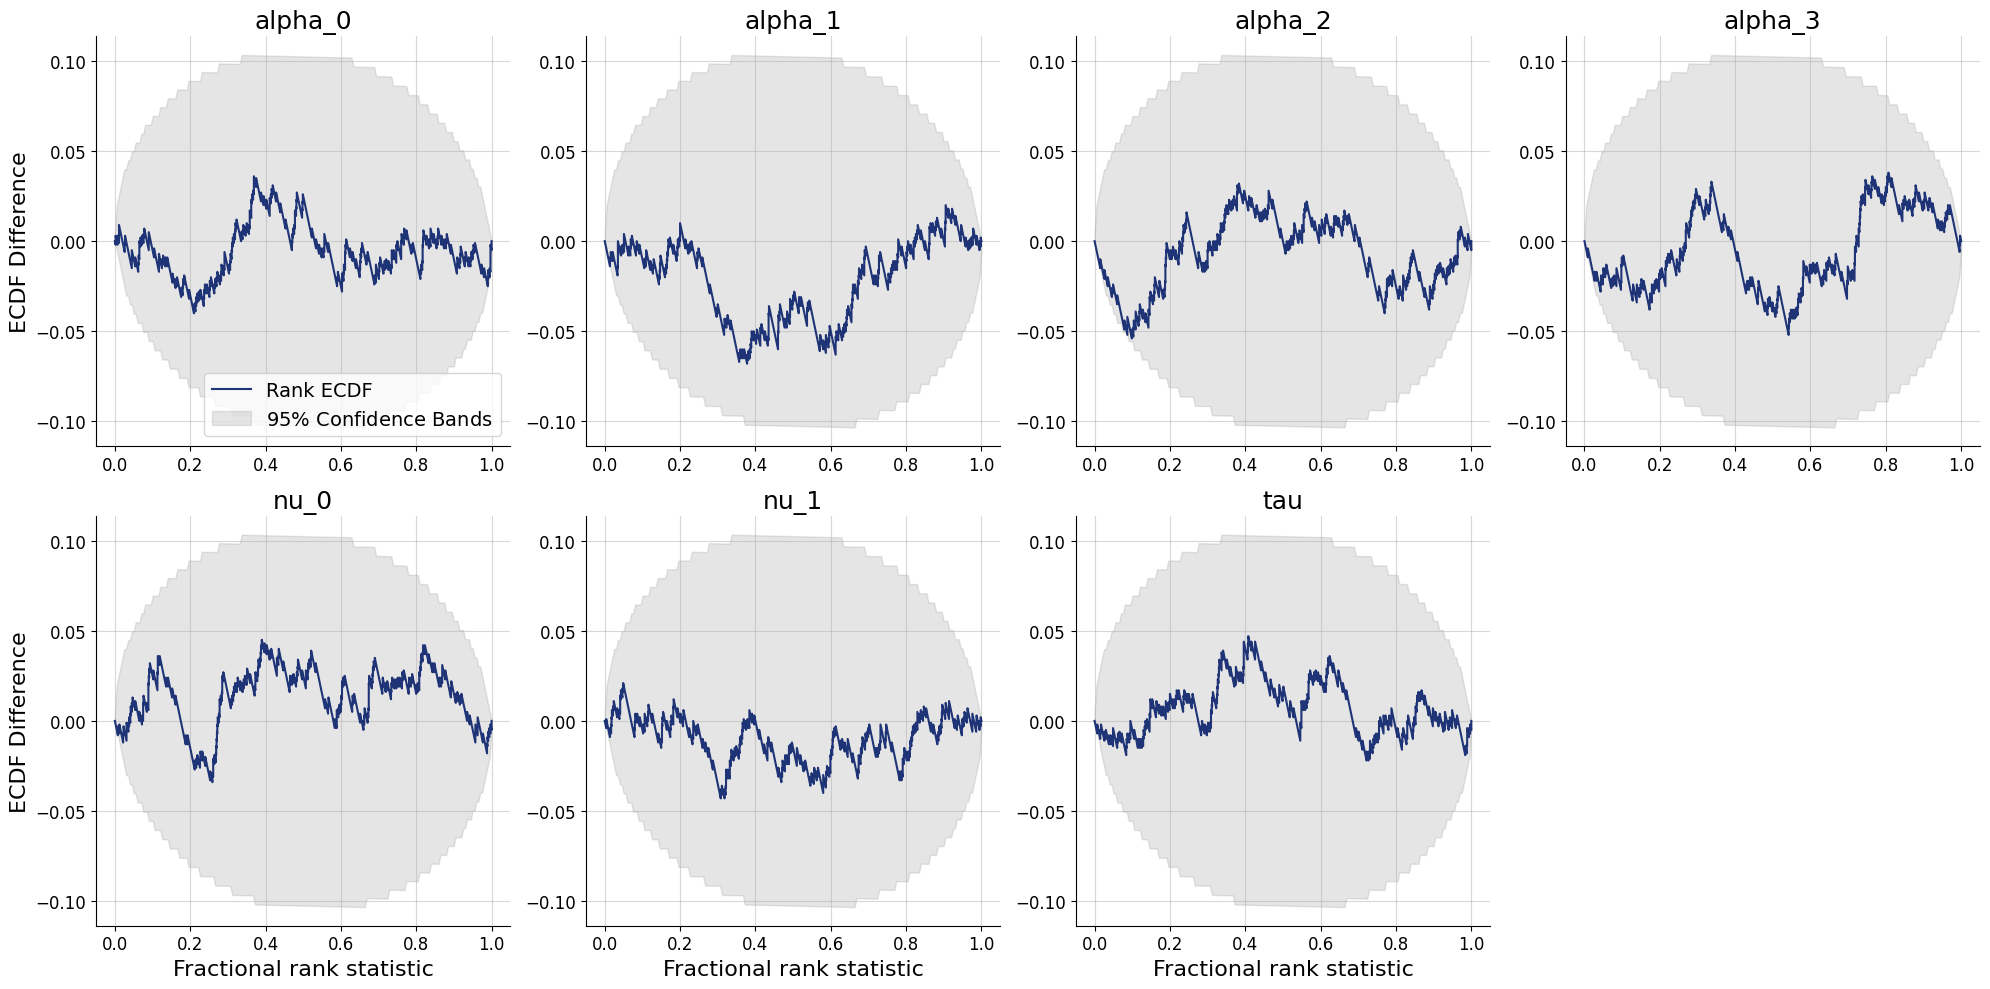

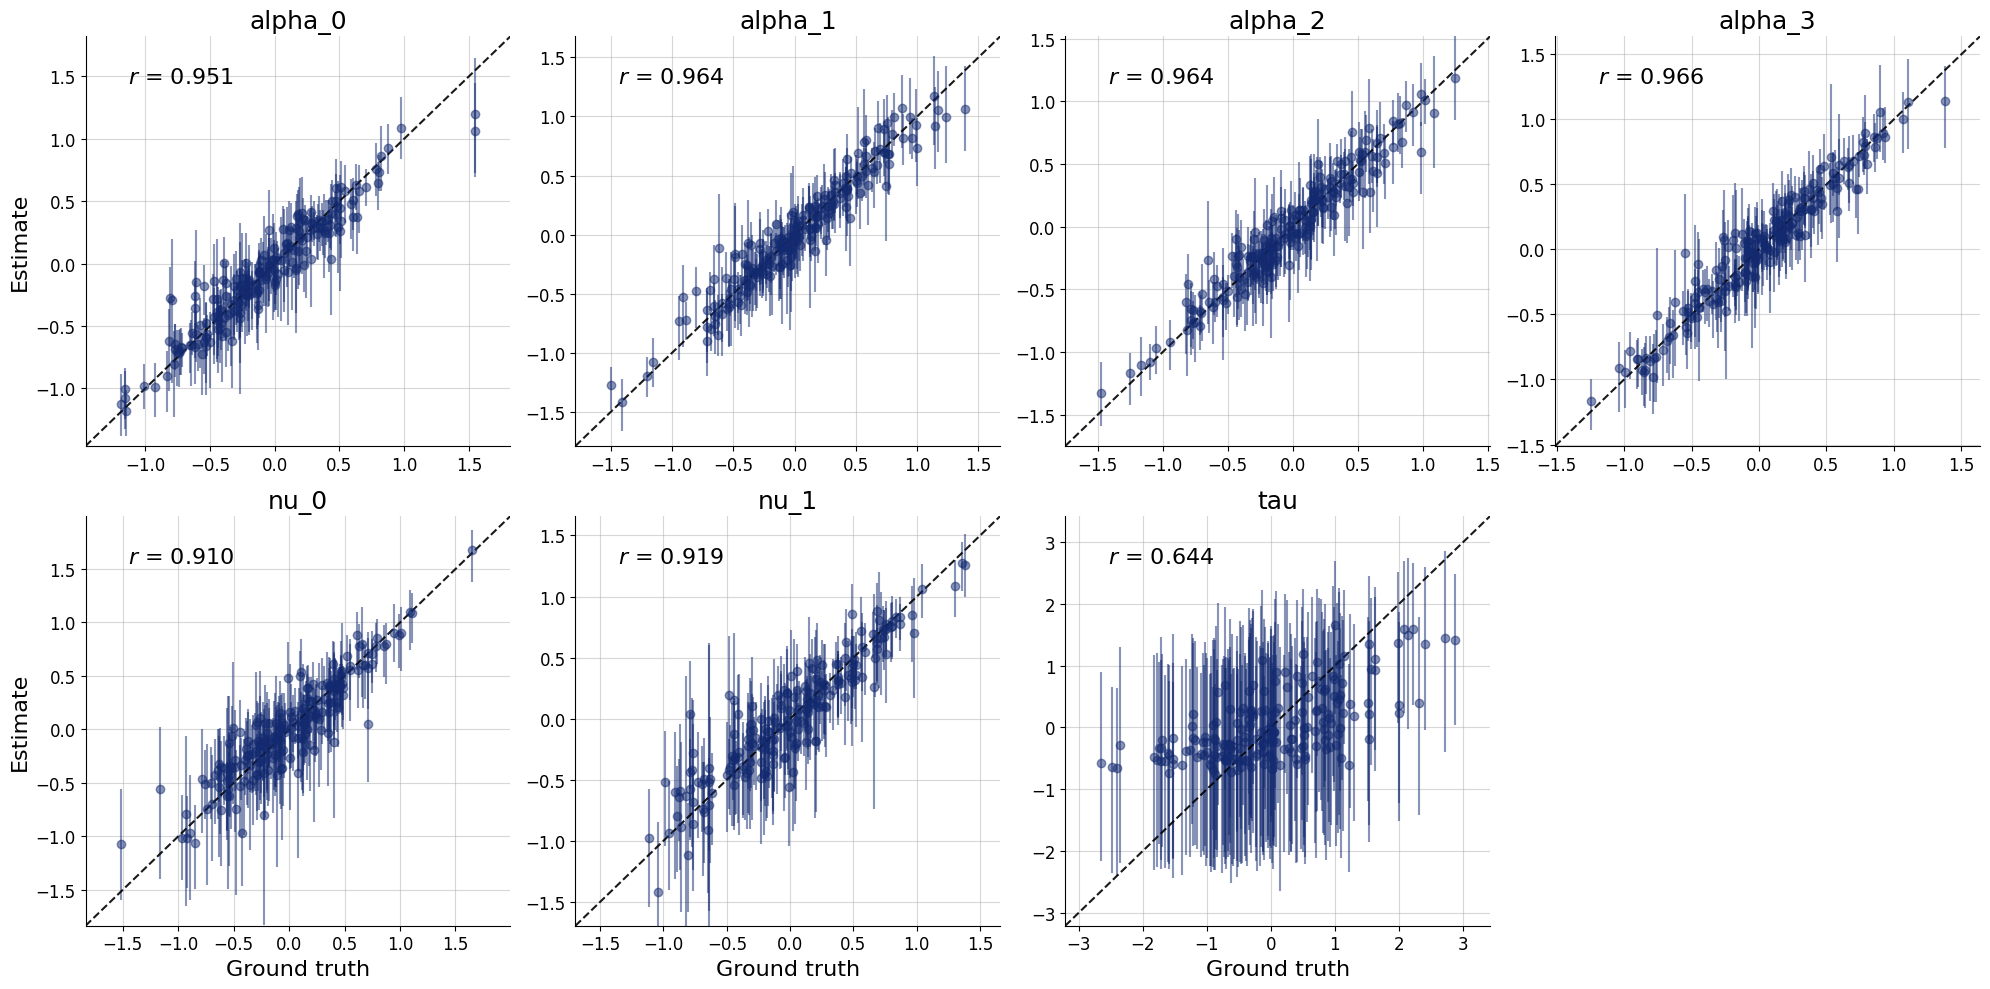

In [11]:
approximators = {model: load_approximator(model, config=config) for model in MODELS}
histories = {model: load_history(model, config=config) for model in MODELS}

for model in MODELS:
    bf.diagnostics.plots.loss(histories[model])

num_samples = 1000
for model in MODELS:
    val_sims = SIMULATORS[model].sample(200)
    post_draws = approximators[model].sample(conditions=val_sims, num_samples=num_samples)
    bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
    bf.diagnostics.plots.recovery(post_draws, val_sims)


## 2. Load empirical datasets

In [12]:
empirical = wagenmakers.df_array
ids = wagenmakers.ids

empirical.shape, ids[:5]

((17, 384, 2), ['p0', 'p1', 'p2', 'p3', 'p4'])

## 3. Estimate NPE logML, logBF, and PMP

In [13]:
results = estimate_model_comparison(
    approximators,
    empirical,
    ids=ids,
    dataset="empirical",
    num_samples=2048,
    batch_size=8,
)

results_gold = attach_gold_standard(results)
save_results(results_gold, results_path)
results_gold.head()


,dataset,id,log_ml_m0,importance_ess_m0,log_ml_m1,importance_ess_m1,log_ml_m2,importance_ess_m2,log_ml_m3,importance_ess_m3,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_log_ml_m0,gold_log_ml_m1,gold_log_ml_m2,gold_log_ml_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,signed_logml_error_m0,signed_pmp_error_m0,abs_pmp_error_m0,signed_logml_error_m1,signed_pmp_error_m1,abs_pmp_error_m1,signed_logml_error_m2,signed_pmp_error_m2,abs_pmp_error_m2,signed_logml_error_m3,signed_pmp_error_m3,abs_pmp_error_m3
0,empirical,p0,72.104454,2.396760,89.385628,7.815466,71.032889,15.331157,84.967569,8.693937,3.087993e-08,9.880860e-01,1.057552e-08,0.011914,71.808556,88.269208,69.808035,84.568990,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,0.295898,-3.840280e-08,3.840280e-08,1.116419,1.220796e-02,1.220796e-02,1.224854,1.204000e-09,1.204000e-09,0.398579,-1.220792e-02,1.220792e-02
1,empirical,p1,10.061827,2.313907,77.314211,7.139291,11.621369,23.613955,79.946955,2.167311,4.160336e-31,6.706060e-02,1.978921e-30,0.932939,11.611132,78.260448,11.943984,79.133195,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,-1.549305,-2.925340e-30,2.925340e-30,-0.946237,-2.276225e-01,2.276225e-01,-0.322616,-2.682097e-30,2.682097e-30,0.813759,2.276225e-01,2.276225e-01
2,empirical,p2,-10.941333,5.662074,39.214203,3.128243,5.527996,29.143240,56.350438,2.772489,5.964242e-30,3.612667e-08,8.474106e-23,1.000000,-10.293330,37.335670,3.969435,57.456636,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,-0.648003,2.192312e-30,2.192312e-30,1.878533,3.430035e-08,3.430035e-08,1.558560,7.884171e-23,7.884171e-23,-1.106198,-3.430036e-08,3.430036e-08
3,empirical,p3,167.473349,8.354453,194.849038,5.539797,168.293243,2.823675,196.008408,5.759805,3.082408e-13,2.387818e-01,6.997869e-13,0.761218,167.837266,195.128890,166.361019,195.426395,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,-0.363917,-2.901412e-13,2.901412e-13,-0.279851,-1.873857e-01,1.873857e-01,1.932224,5.630604e-13,5.630604e-13,0.582014,1.873857e-01,1.873857e-01
4,empirical,p4,147.359019,114.799390,225.190027,12.703174,146.655188,55.293381,220.715976,10.978856,1.561346e-34,9.887275e-01,7.723769e-35,0.011273,145.813723,223.169374,144.080511,219.278042,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,1.545296,-9.280229e-35,9.280229e-35,2.020653,8.737059e-03,8.737059e-03,2.574677,3.324660e-35,3.324660e-35,1.437934,-8.737059e-03,8.737059e-03


## 4. Build summary-space typical sets

In [14]:
references = fit_references(
    approximators,
    SIMULATORS,
    n_fit=2000,
    n_calibration=2000,
    alpha=0.05,
    metric="l2",
    n_boot=1000,
)

save_references(references, references_path)
{model: {key: references[model][key] for key in ["summary_dim", "median", "low", "high"]} for model in references}


{'m0': {'summary_dim': 8,
  'median': 0.7591857702247592,
  'low': 0.39319387975226894,
  'high': 1.9526759265715723},
 'm1': {'summary_dim': 10,
  'median': 0.7669913301983474,
  'low': 0.4361818328554101,
  'high': 2.027726489477065},
 'm2': {'summary_dim': 10,
  'median': 0.8375234538047017,
  'low': 0.5111981718106153,
  'high': 1.953117713409515},
 'm3': {'summary_dim': 14,
  'median': 0.8295447051608005,
  'low': 0.5112638827783039,
  'high': 1.7292503712655853}}

## 5. Add summary diagnostics to empirical results

In [15]:
diagnostic = add_summary_diagnostics(results_gold, empirical, approximators, references)
save_diagnostic(diagnostic, diagnostic_path)

display_columns = (
    ["id"]
    + [f"rho_{model}" for model in MODELS]
    + [f"regime_{model}" for model in MODELS]
    + ["summary_ambiguity"]
    + [f"pmp_{model}" for model in MODELS]
    + [f"gold_pmp_{model}" for model in MODELS]
    + [f"abs_pmp_error_{model}" for model in MODELS]
)
diagnostic[display_columns].head(20)


,id,rho_m0,rho_m1,rho_m2,rho_m3,regime_m0,regime_m1,regime_m2,regime_m3,summary_ambiguity,pmp_m0,pmp_m1,pmp_m2,pmp_m3,gold_pmp_m0,gold_pmp_m1,gold_pmp_m2,gold_pmp_m3,abs_pmp_error_m0,abs_pmp_error_m1,abs_pmp_error_m2,abs_pmp_error_m3
0,p0,0.869045,0.681288,0.708216,0.597470,in_distribution,in_distribution,in_distribution,in_distribution,0.0,3.087993e-08,9.880860e-01,1.057552e-08,0.011914,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,3.840280e-08,1.220796e-02,1.204000e-09,1.220792e-02
1,p1,1.202865,1.007113,0.672915,0.813488,high surprise,high surprise,in_distribution,in_distribution,0.0,4.160336e-31,6.706060e-02,1.978921e-30,0.932939,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,2.925340e-30,2.276225e-01,2.682097e-30,2.276225e-01
2,p2,1.155395,0.902547,0.911396,0.792748,high surprise,in_distribution,in_distribution,in_distribution,0.0,5.964242e-30,3.612667e-08,8.474106e-23,1.000000,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,2.192312e-30,3.430035e-08,7.884171e-23,3.430036e-08
3,p3,1.180615,0.923231,0.750529,0.778930,high surprise,in_distribution,in_distribution,in_distribution,0.0,3.082408e-13,2.387818e-01,6.997869e-13,0.761218,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,2.901412e-13,1.873857e-01,5.630604e-13,1.873857e-01
4,p4,1.190893,0.892388,0.825444,0.716938,high surprise,in_distribution,in_distribution,in_distribution,0.0,1.561346e-34,9.887275e-01,7.723769e-35,0.011273,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,9.280229e-35,8.737059e-03,3.324660e-35,8.737059e-03
5,p5,0.957550,0.772907,0.834029,0.649932,in_distribution,in_distribution,in_distribution,in_distribution,0.0,3.044432e-16,3.928724e-01,1.039671e-14,0.607128,1.466121e-15,4.169979e-01,7.539907e-15,0.583002,1.161678e-15,2.412543e-02,2.856799e-15,2.412543e-02
6,p6,0.763902,0.669991,1.032929,0.601299,in_distribution,in_distribution,high surprise,in_distribution,0.0,2.729292e-10,2.998355e-09,1.570643e-03,0.998429,1.568121e-10,4.284786e-06,1.730393e-03,0.998265,1.161171e-10,4.281788e-06,1.597500e-04,1.640317e-04
7,p7,0.870648,0.568546,0.758310,0.564027,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.829839e-53,4.331109e-01,2.186044e-54,0.566889,5.970915e-54,5.973384e-01,8.052601e-55,0.402662,1.232747e-53,1.642275e-01,1.380784e-54,1.642275e-01
8,p8,0.979903,0.682317,0.785965,0.663160,in_distribution,in_distribution,in_distribution,in_distribution,0.0,1.038783e-32,1.473435e-05,8.685698e-29,0.999985,1.810249e-31,7.591326e-05,1.027280e-28,0.999924,1.706371e-31,6.117890e-05,1.587103e-29,6.117890e-05
9,p9,1.149121,0.953411,0.905996,0.792399,high surprise,in_distribution,in_distribution,in_distribution,0.0,3.890674e-15,3.527845e-02,8.417853e-12,0.964722,6.340414e-15,5.671474e-02,2.639804e-12,0.943285,2.449740e-15,2.143630e-02,5.778049e-12,2.143630e-02


## 6. Load cached tables for plotting

After the computations above have been saved once, you can restart the kernel and run this cell before plotting.


In [16]:
# Uncomment these lines to plot from saved results without recomputing logML or reference distances.
results_gold = load_results(results_path)
references = load_references(references_path)
diagnostic = load_diagnostic(diagnostic_path)


## 7. Basic plots


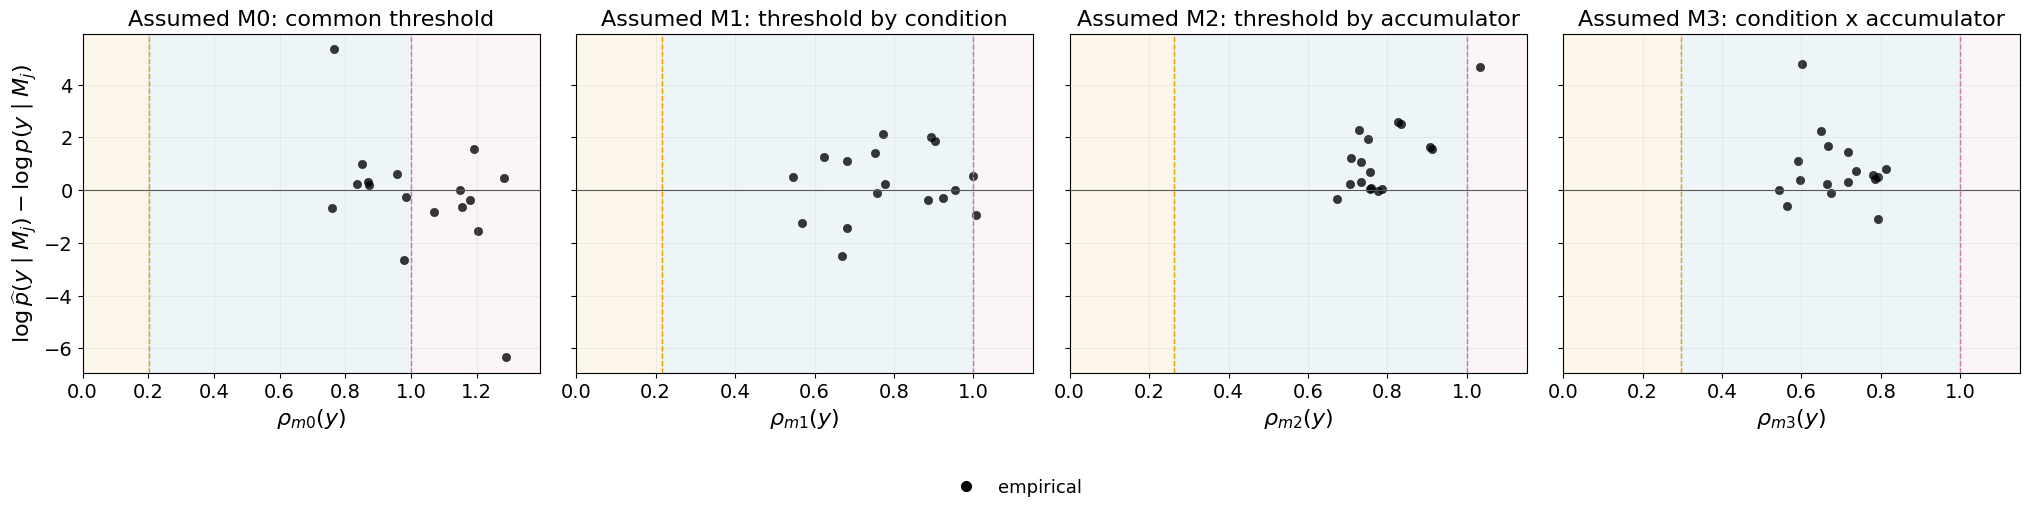

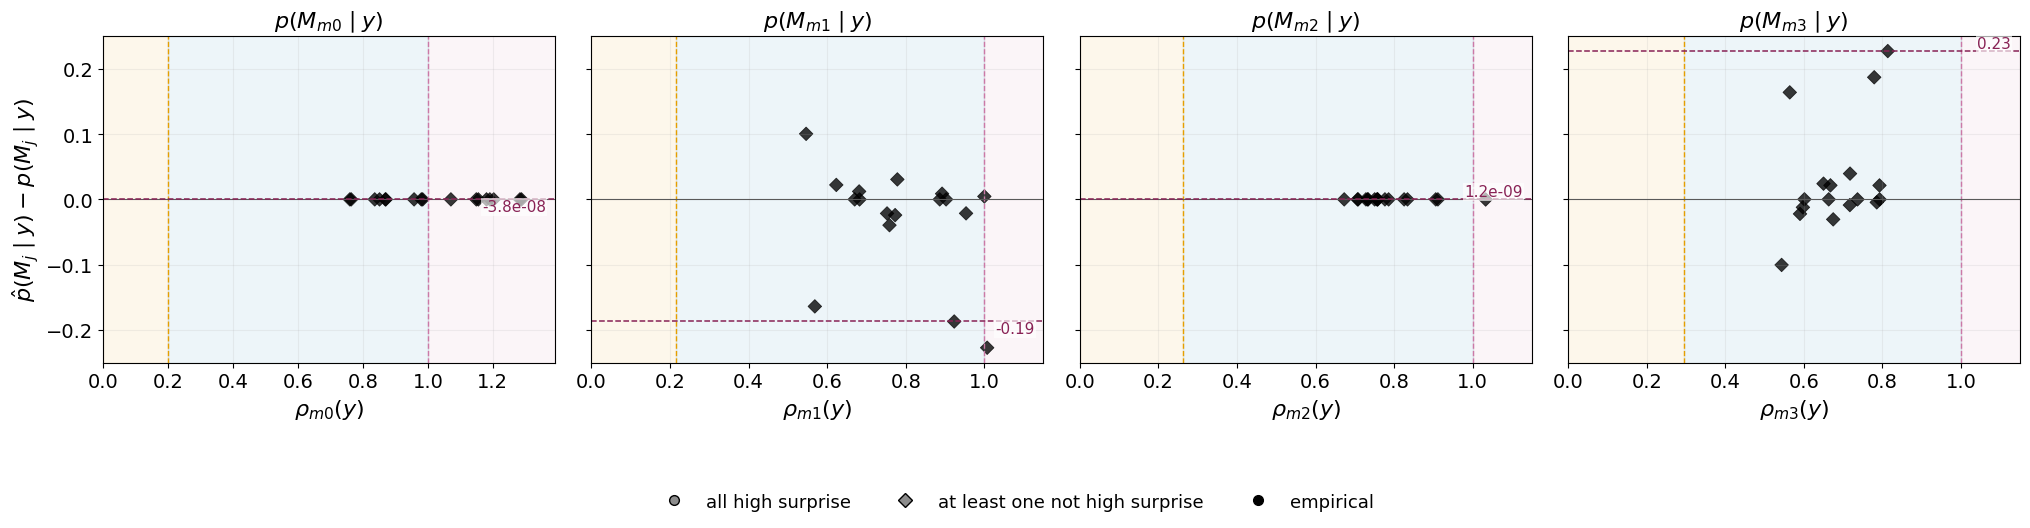

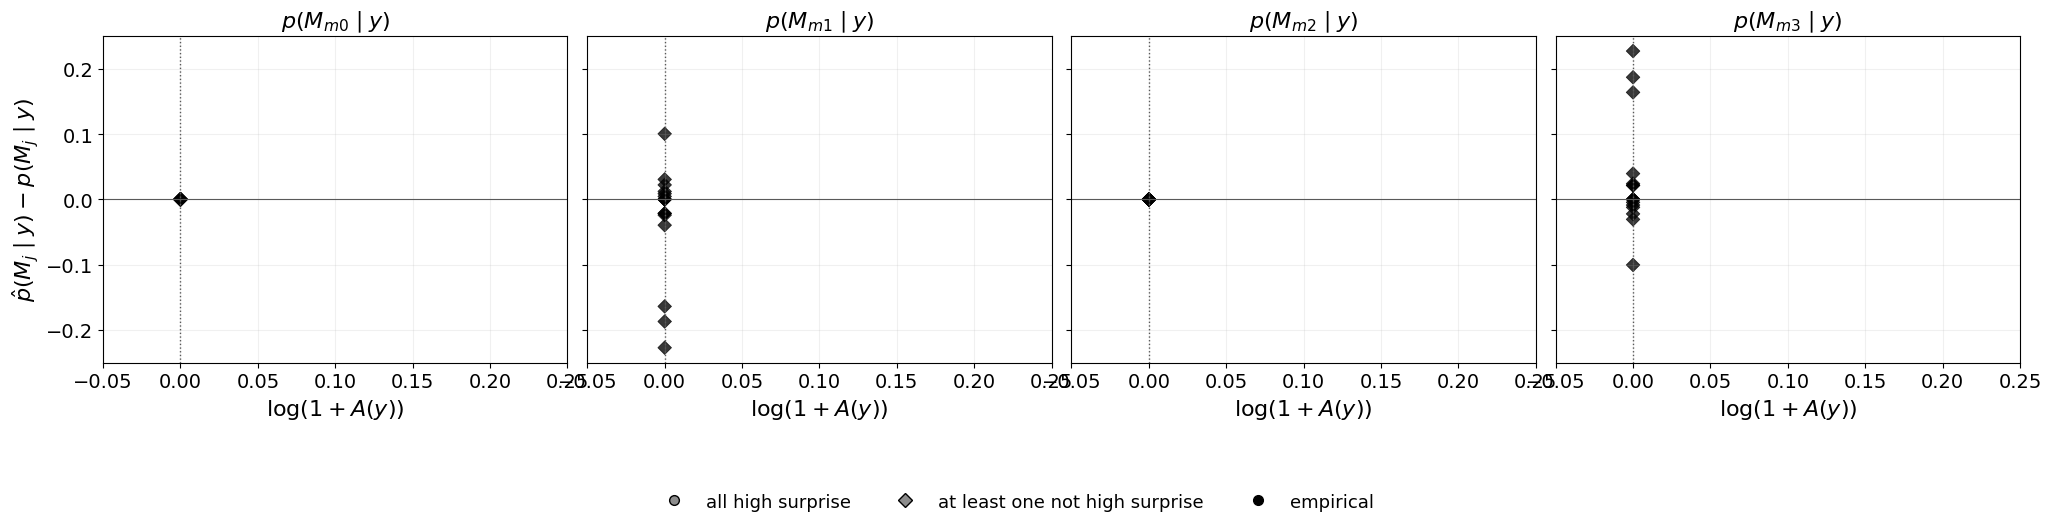

In [17]:
plot_logml_error_vs_rho(diagnostic, filename=f"npe_logml_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_rho(diagnostic, filename=f"npe_pmp_error_vs_rho_{summary_tag}.png");
plot_pmp_error_vs_log_ambiguity(diagnostic, filename=f"npe_pmp_error_vs_log_ambiguity_{summary_tag}.png");

## 8. PMP Estimates vs Distance

Compare the NPE posterior model probability estimate with the Stan gold-standard PMP over summary distance.

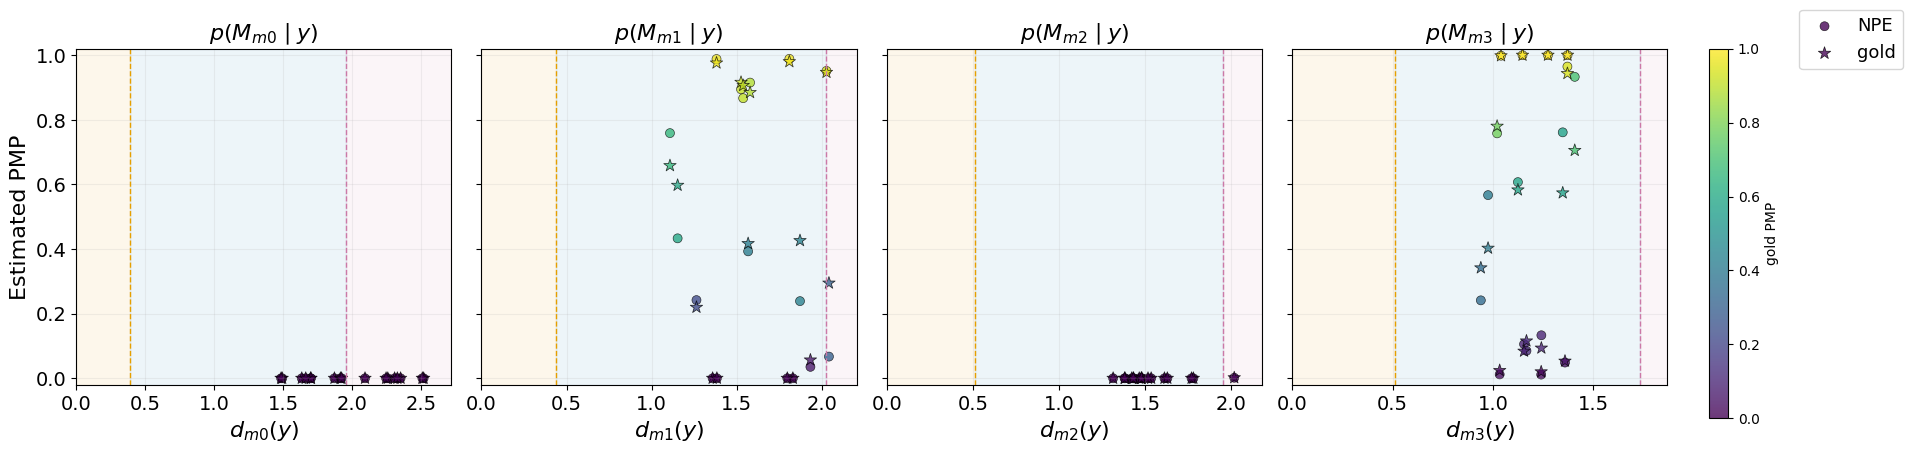

In [18]:
fig_pmp_estimates_distance, axes_pmp_estimates_distance = plot_pmp_estimates_vs_distance(
    diagnostic,
    x="distance",
    y="estimate",
    filename=f"npe_pmp_estimates_vs_distance_{summary_tag}.png",
)
